# Heart Disease Prediction using Decision Tree

## Objective
The objective of this project is to build a Decision Tree Classifier that predicts whether a patient has heart disease based on medical attributes.

### Workflow
- Import Libraries
- Load Dataset
- Explore Dataset
- Data Visualization
- Data Preprocessing
- Train-Test Split
- Train Decision Tree Model
- Model Evaluation
- Feature Importance
- Decision Tree Visualization
- Conclusion

# Import **libraries**

In [68]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)


# Load dataset from kaggle


In [39]:
df = pd.read_csv("heart.csv")
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,Yes,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,Yes,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,Yes,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,No,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,No,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


In [40]:
df.tail()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
9995,25.0,Female,136.0,243.0,Medium,Yes,No,No,18.788791,Yes,No,Yes,Medium,High,6.834954,Medium,343.0,133.0,3.588814,19.132004,Yes
9996,38.0,Male,172.0,154.0,Medium,No,No,No,31.856801,Yes,No,Yes,NaN,High,8.247784,Low,377.0,83.0,2.658267,9.715709,Yes
9997,73.0,Male,152.0,201.0,High,Yes,No,Yes,26.899911,No,Yes,Yes,NaN,Low,4.436762,Low,248.0,88.0,4.408867,9.492429,Yes
9998,23.0,Male,142.0,299.0,Low,Yes,No,Yes,34.964026,Yes,No,Yes,Medium,High,8.526329,Medium,113.0,153.0,7.215634,11.873486,Yes
9999,38.0,Female,128.0,193.0,Medium,Yes,Yes,Yes,25.111295,No,Yes,Yes,High,Medium,5.659394,High,121.0,149.0,14.387810,6.208531,Yes


In [41]:
# dataset shapes
print("Number of rows and columns :", df.shape)


Number of rows and columns : (10000, 21)


In [42]:
# Column names
df.columns

Index(['Age', 'Gender', 'Blood Pressure', 'Cholesterol Level',
       'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'BMI',
       'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol',
       'Alcohol Consumption', 'Stress Level', 'Sleep Hours',
       'Sugar Consumption', 'Triglyceride Level', 'Fasting Blood Sugar',
       'CRP Level', 'Homocysteine Level', 'Heart Disease Status'],
      dtype='object')

In [43]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   object 
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   object 
 5   Smoking               9975 non-null   object 
 6   Family Heart Disease  9979 non-null   object 
 7   Diabetes              9970 non-null   object 
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   object 
 10  Low HDL Cholesterol   9975 non-null   object 
 11  High LDL Cholesterol  9974 non-null   object 
 12  Alcohol Consumption   7414 non-null   object 
 13  Stress Level          9978 non-null   object 
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption   

In [44]:
# statistical summary
df.describe()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
count,9971.000000,9981.000000,9970.000000,9978.000000,9975.000000,9974.000000,9978.000000,9974.000000,9980.000000
mean,49.296259,149.757740,225.425577,29.077269,6.991329,250.734409,120.142213,7.472201,12.456271
std,18.193970,17.572969,43.575809,6.307098,1.753195,87.067226,23.584011,4.340248,4.323426
min,18.000000,120.000000,150.000000,18.002837,4.000605,100.000000,80.000000,0.003647,5.000236
25%,34.000000,134.000000,187.000000,23.658075,5.449866,176.000000,99.000000,3.674126,8.723334
50%,49.000000,150.000000,226.000000,29.079492,7.003252,250.000000,120.000000,7.472164,12.409395
75%,65.000000,165.000000,263.000000,34.520015,8.531577,326.000000,141.000000,11.255592,16.140564
max,80.000000,180.000000,300.000000,39.996954,9.999952,400.000000,160.000000,14.997087,19.999037


In [45]:
# chaek missing value
df.isnull().sum()

,0
Age,29
Gender,19
Blood Pressure,19
Cholesterol Level,30
Exercise Habits,25
Smoking,25
Family Heart Disease,21
Diabetes,30
BMI,22
High Blood Pressure,26


In [46]:
# Check duplictae rows
print("Duplicate rows:",df.duplicated().sum())

Duplicate rows: 0


In [47]:
# separate numerical and categorical columns

numerical_cols = df.select_dtypes(include=['float64','int64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(numerical_cols)

print("\n Categorical Columns:")
print(categorical_cols)


Numerical Columns:
Index(['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours',
       'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level',
       'Homocysteine Level'],
      dtype='object')

 Categorical Columns:
Index(['Gender', 'Exercise Habits', 'Smoking', 'Family Heart Disease',
       'Diabetes', 'High Blood Pressure', 'Low HDL Cholesterol',
       'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level',
       'Sugar Consumption', 'Heart Disease Status'],
      dtype='object')


In [48]:
# Fill missing values

# numerical -> median
for col in numerical_cols:
   df[col] = df[col].fillna(df[col].median())

# categorical -> Mode
for col in categorical_cols:
  df[col] = df[col].fillna(df[col].mode()[0])

In [49]:
df.isnull().sum()

,0
Age,0
Gender,0
Blood Pressure,0
Cholesterol Level,0
Exercise Habits,0
Smoking,0
Family Heart Disease,0
Diabetes,0
BMI,0
High Blood Pressure,0


In [50]:
# Label Encoding

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

for col in categorical_cols:
  df[col] = label_encoder.fit_transform(df[col])

df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,1,153.0,155.0,0,1,1,0,24.991591,1,1,0,0,2,7.633228,2,342.0,120.0,12.969246,12.387250,0
1,69.0,0,146.0,286.0,0,0,1,1,25.221799,0,1,0,2,0,8.744034,2,133.0,157.0,9.355389,19.298875,0
2,46.0,1,126.0,216.0,1,0,0,0,29.855447,0,1,1,1,1,4.440440,1,393.0,92.0,12.709873,11.230926,0
3,32.0,0,122.0,293.0,0,1,1,0,24.130477,1,0,1,1,0,5.249405,0,293.0,94.0,12.509046,5.961958,0
4,60.0,1,166.0,242.0,1,1,1,1,20.486289,1,0,0,1,0,7.030971,0,263.0,154.0,10.381259,8.153887,0


In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   10000 non-null  float64
 1   Gender                10000 non-null  int64  
 2   Blood Pressure        10000 non-null  float64
 3   Cholesterol Level     10000 non-null  float64
 4   Exercise Habits       10000 non-null  int64  
 5   Smoking               10000 non-null  int64  
 6   Family Heart Disease  10000 non-null  int64  
 7   Diabetes              10000 non-null  int64  
 8   BMI                   10000 non-null  float64
 9   High Blood Pressure   10000 non-null  int64  
 10  Low HDL Cholesterol   10000 non-null  int64  
 11  High LDL Cholesterol  10000 non-null  int64  
 12  Alcohol Consumption   10000 non-null  int64  
 13  Stress Level          10000 non-null  int64  
 14  Sleep Hours           10000 non-null  float64
 15  Sugar Consumption   

# Exploratory Data Analysis (EDA)

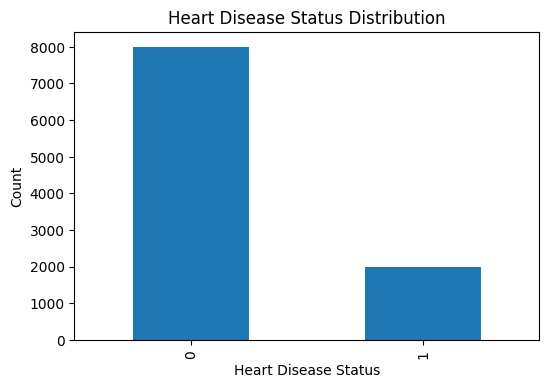

In [52]:
# Calss Distribution

df["Heart Disease Status"].value_counts().plot(kind ="bar", figsize=(6,4))

plt.title("Heart Disease Status Distribution")
plt.xlabel("Heart Disease Status")
plt.ylabel("Count")
plt.savefig("heart_disease_status_distribution.png", dpi = 300, bbox_inches ="tight")
plt.show()

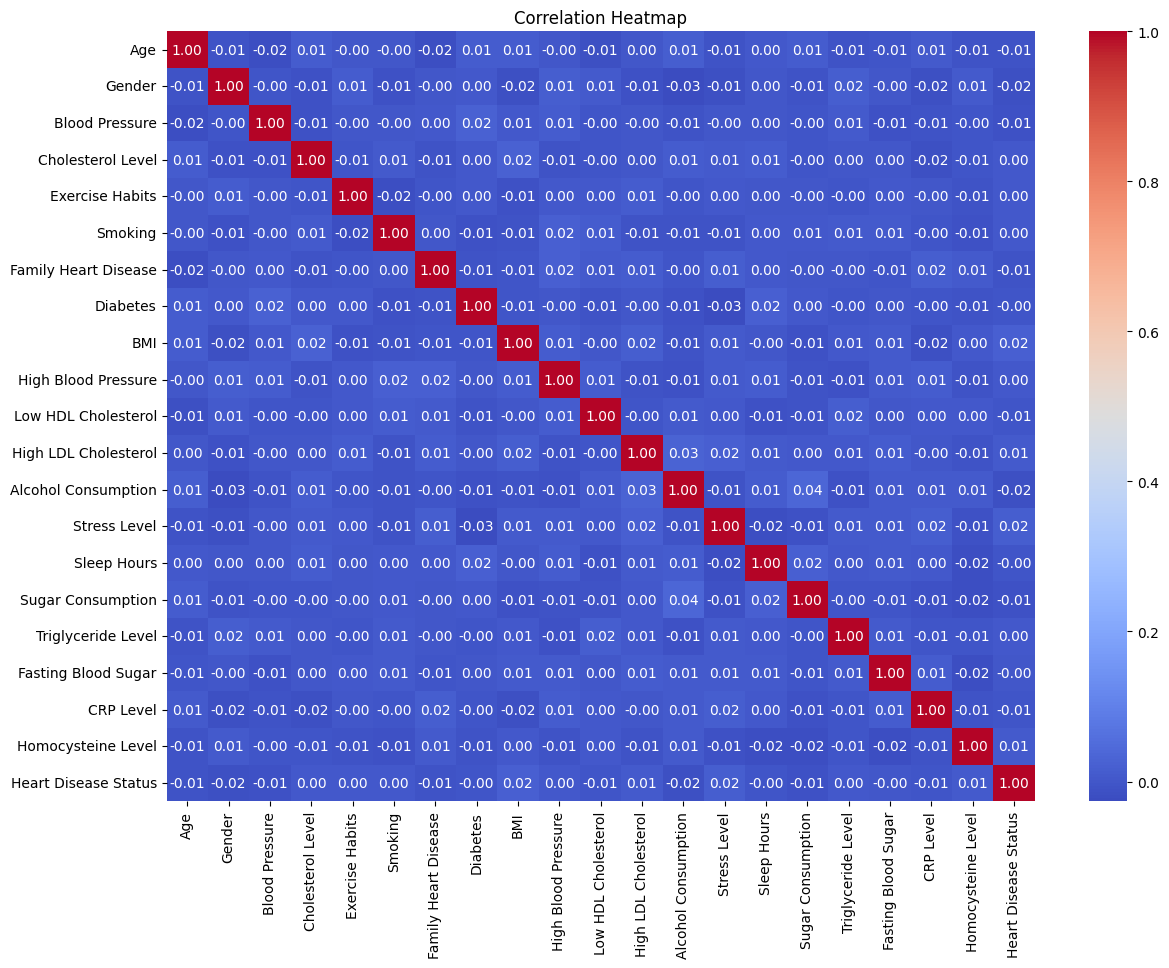

In [53]:
# Heatmap

plt.figure(figsize=(14,10))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png", dpi = 300, bbox_inches ="tight")
plt.show()

#Define Features (X) and Target (y)

In [54]:
X = df.drop("Heart Disease Status", axis = 1)

y = df["Heart Disease Status"]


X_train,X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [55]:
print("Shape of X_train:",X_train.shape)
print("Shape of X_test:",X_test.shape)
print("Shape of y_train:",y_train.shape)
print("Shape of y_test:",y_test.shape)

Shape of X_train: (8000, 20)
Shape of X_test: (2000, 20)
Shape of y_train: (8000,)
Shape of y_test: (2000,)


In [56]:
# Train the decision tree
model = DecisionTreeClassifier(random_state = 42)

model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [57]:
# Make prediction

y_pred = model.predict(X_test)

In [58]:
print("Ypred:", y_pred[:10])

Ypred: [0 0 0 0 0 0 0 0 0 0]


In [59]:
# Check accuracy score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.6685


# Confusion Matrix

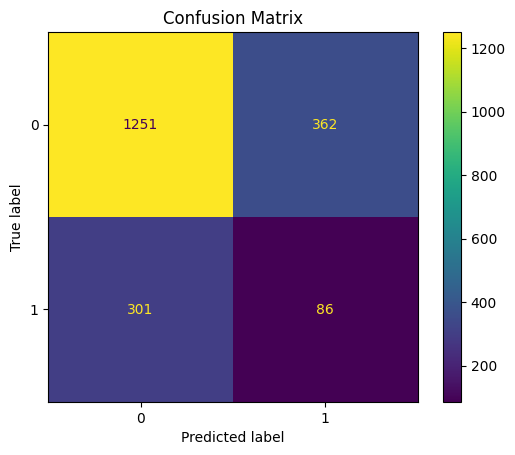

In [60]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# Classifiaction report

In [61]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.78      0.79      1613
           1       0.19      0.22      0.21       387

    accuracy                           0.67      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.69      0.67      0.68      2000



# Feature importance

In [64]:
feature_imp = pd.Series(
    model.feature_importances_,
    index = X.columns
).sort_values(ascending = False)

feature_imp

,0
BMI,0.110066
CRP Level,0.106564
Sleep Hours,0.106057
Homocysteine Level,0.102417
Triglyceride Level,0.087790
Fasting Blood Sugar,0.084807
Cholesterol Level,0.083956
Age,0.081062
Blood Pressure,0.071818
Stress Level,0.025552


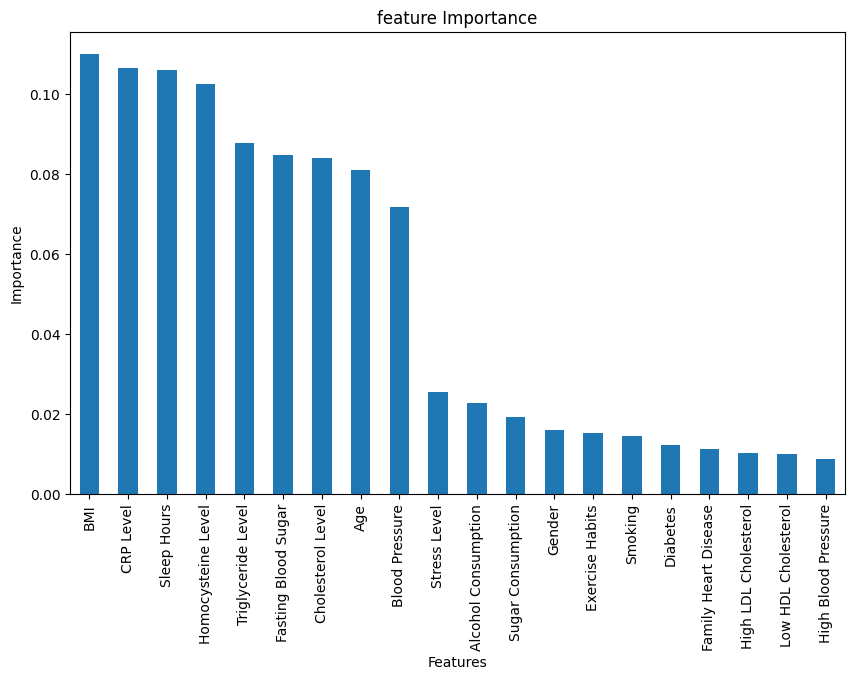

In [67]:

plt.figure(figsize=(10,6))

feature_imp.plot(kind="bar")

plt.title("feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.savefig("feature_importance.png",dpi=300, bbox_inches="tight")
plt.show()


# Decision Tree Visualization

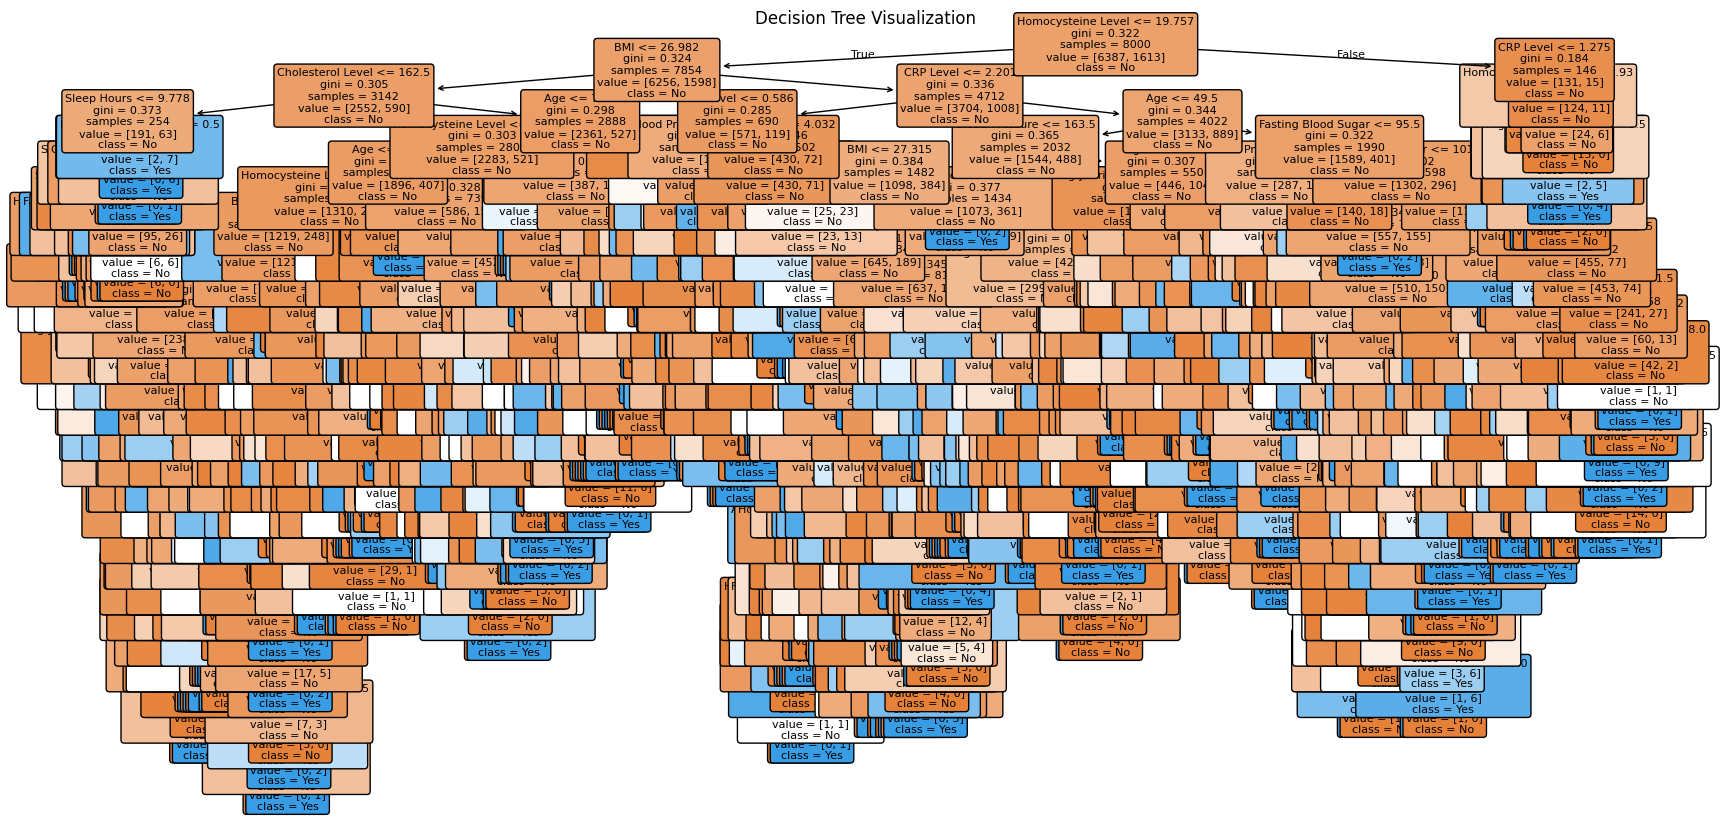

In [69]:
plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No", "Yes"],
    filled=True,
    rounded= True,
    fontsize=8
)

plt.title("Decision Tree Visualization")
plt.savefig("decision_tree_visualization.png", dpi=300, bbox_inches="tight")
plt.show()

In [70]:
train_pred = model.predict(X_train)

train_accuracy = accuracy_score(y_train, train_pred)

print(f"Train Accuracy: {train_accuracy:.2%}")
print(f"Testing Accuracy : {accuracy:.2%}")

Train Accuracy: 100.00%
Testing Accuracy : 66.85%


Train Accuracy: 100.00%
Testing Accuracy : 66.85%
model is overfitting we to resolve this issue


In [72]:
model2 = DecisionTreeClassifier(max_depth=2, random_state=42)

model2.fit(X_train, y_train)

y_pred2 = model2.predict(X_test)

print(f"Testing Accuracy : {accuracy_score(y_test, y_pred2):.2%}")

Testing Accuracy : 80.65%


In [74]:
train_accuracy1 = accuracy_score(y_train, model2.predict(X_train))

print(f"Train Accuracy: {train_accuracy1:.2%}")

Train Accuracy: 79.84%


## Model Improvement (Pre-Pruning)

The initial Decision Tree achieved an accuracy of **66.85%** on the test set.

To reduce overfitting and improve generalization, the `max_depth` parameter was set to **2**.

Results:

- Training Accuracy: **79.84%**
- Testing Accuracy: **80.65%**

The pruned Decision Tree performed significantly better than the default model, indicating that limiting the tree depth improved its ability to generalize to unseen data.

# Experiment: Finding the Best max_depth

In [75]:
depths = range(1, 11)
train_scores = []
test_scores = []

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))


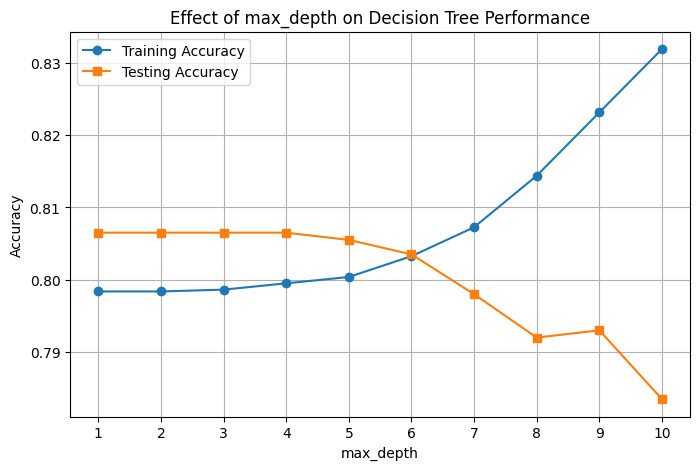

In [78]:
# plot
plt.figure(figsize=(8,5))

plt.plot(depths, train_scores, marker='o', label="Training Accuracy")
plt.plot(depths, test_scores, marker='s', label="Testing Accuracy")

plt.title("Effect of max_depth on Decision Tree Performance")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.xticks(depths)
plt.legend()
plt.grid(True)

plt.savefig("max_depth_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [77]:
# Find the best depth

best_depth = depths[test_scores.index(max(test_scores))]

print("Best max_depth:", best_depth)
print("Best Test Accuracy:", max(test_scores))

Best max_depth: 1
Best Test Accuracy: 0.8065


# Conclusion

In this project, a Decision Tree Classifier was developed to predict heart disease based on patient health information.

## Key Steps Performed
- Loaded and explored the dataset.
- Handled missing values using median and mode imputation.
- Converted categorical features into numerical values using Label Encoding.
- Performed Exploratory Data Analysis (EDA).
- Split the dataset into training and testing sets.
- Trained a Decision Tree Classifier.
- Evaluated the model using accuracy, confusion matrix, and classification report.
- Analyzed feature importance.
- Visualized the Decision Tree.
- Tuned the `max_depth` hyperparameter to improve model performance.

## Results
- Default Decision Tree Accuracy: **66.85%**
- Optimized Decision Tree Accuracy (`max_depth = 2`): **80.65%**

The optimized model achieved better generalization by reducing the complexity of the tree, demonstrating the importance of hyperparameter tuning in machine learning.

# Future Improvements

- Perform feature selection.
- Use GridSearchCV for hyperparameter tuning.
- Compare Decision Tree with Random Forest and XGBoost.
- Apply cross-validation for more reliable evaluation.
- Deploy the trained model using Flask or Streamlit.